In [1]:
import logging
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import scipy.stats as stat

from utils import (
    load_splits,
    build_dataset_from_ids,
    compute_bounding_box, bbox_to_padded_shape,
    load_brain_mask,
    load_preprocessing_stats
)

from evaluate import (
    _apply_norm, _denormalize,
    subject_metrics, evaluate_model, summarize
)

from compare import _print_table
from config import Config
from pathlib import Path
import json

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# Reconstructions comparison 
- plot rec quality vs dims

In [2]:
SPLIT = "test"
base_cfg = Config()
device = base_cfg.device
out_dir = Path(base_cfg.jsons_dir)

stats = load_preprocessing_stats(str(out_dir / "preprocessing_stats.json"))
splits = load_splits(base_cfg.splits_dir)

with open(out_dir / "id_to_cohort.json") as f:
    id_to_cohort = json.load(f)

cache_dir = base_cfg.cache_dir if Path(base_cfg.cache_dir).exists() else None
raw_cfg = Config()
raw_cfg.normalisation = "none"
raw_dataset = build_dataset_from_ids(
    splits[SPLIT], id_to_cohort, raw_cfg,
    bbox=stats["bbox"], padded_shape=stats["padded_shape"],
    norm_mean=None, norm_std=None, normalisation="none",
    cache_dir=cache_dir,
    )

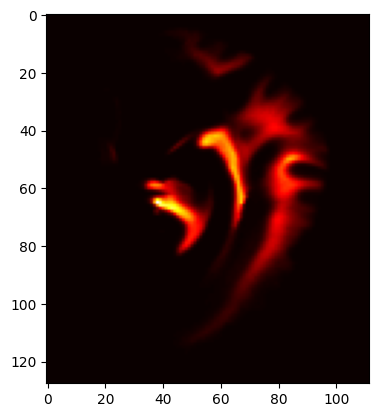

In [3]:
plt.imshow(raw_dataset[5][0][60], cmap='hot')

In [4]:
stats

{'bbox': {'z_min': 16,
  'z_max': 115,
  'y_min': 16,
  'y_max': 140,
  'x_min': 3,
  'x_max': 104},
 'padded_shape': (112, 128, 112),
 'norm_mean': 15.940274029018573,
 'norm_std': 65.34034382271614,
 'log1p_norm_mean': 0.7209655145793625,
 'log1p_norm_std': 1.4584000327893905}

In [5]:
_LATENT_DIMS = [2, 4, 6, 8, 12, 16, 32, 64, 128]

results = {}
for dim in _LATENT_DIMS:
    cfg = Config()
    cfg.latent_dim = dim
    cfg.normalisation = "zscore"
    cfg.use_lr_scheduler = True
    logger.info("--- %s ---", cfg.run_tag)
    per_subject = evaluate_model(cfg, raw_dataset, stats, device)
    if per_subject is not None:
        results[cfg.run_tag] = summarize(per_subject)

INFO | --- latent2_zscore_cosinelr ---
INFO | --- latent4_zscore_cosinelr ---
INFO | --- latent6_zscore_cosinelr ---
INFO | --- latent8_zscore_cosinelr ---
INFO | --- latent12_zscore_cosinelr ---
INFO | --- latent16_zscore_cosinelr ---
INFO | --- latent32_zscore_cosinelr ---
INFO | --- latent64_zscore_cosinelr ---
INFO | --- latent128_zscore_cosinelr ---


In [ ]:
out = out_dir / "dimarison_latent_dims.json"
out.write_text(json.dumps(results, indent=2))
logger.info("Saved -> %s", out)

INFO | Saved -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/jsons/comparison_latent_dims.json


In [5]:
out = out_dir / "comparison_latent_dims.json"
results = json.loads(out.read_text())

In [6]:
_print_table(results)


Run                                      R² ± std_err       MAE  Pearson r     SSIM
------------------------------------------------------------------------------------
latent128_zscore_cosinelr            0.9490 ± 0.0081    1.2578     0.9743   0.9892
latent64_zscore_cosinelr             0.9384 ± 0.0102    1.3476     0.9675   0.9873
latent32_zscore_cosinelr             0.9217 ± 0.0119    1.6183     0.9565   0.9812
latent16_zscore_cosinelr             0.8984 ± 0.0137    1.9850     0.9404   0.9763
latent12_zscore_cosinelr             0.8886 ± 0.0142    1.9091     0.9361   0.9769
latent8_zscore_cosinelr              0.8676 ± 0.0149    2.0741     0.9224   0.9738
latent6_zscore_cosinelr              0.8514 ± 0.0172    2.1682     0.9129   0.9714
latent4_zscore_cosinelr              0.8371 ± 0.0172    2.5045     0.9010   0.9643
latent2_zscore_cosinelr              0.6949 ± 0.0299    3.3648     0.8297   0.9441


In [7]:
r2_results = [metric['r2'] for tag, metric in results.items()]
r2_results

[{'mean': 0.6948915928002172, 'std_err': 0.029904107006653666},
 {'mean': 0.8371156070056378, 'std_err': 0.017219542855952674},
 {'mean': 0.8514275506838856, 'std_err': 0.017157913597807717},
 {'mean': 0.8675606046747041, 'std_err': 0.014941135632452444},
 {'mean': 0.8886286288299816, 'std_err': 0.014223466442799738},
 {'mean': 0.8983545555364365, 'std_err': 0.013725178110130104},
 {'mean': 0.9217428449016289, 'std_err': 0.011921866190992381},
 {'mean': 0.9384310201510487, 'std_err': 0.010245820478516555},
 {'mean': 0.9490469350110764, 'std_err': 0.008114472691544}]

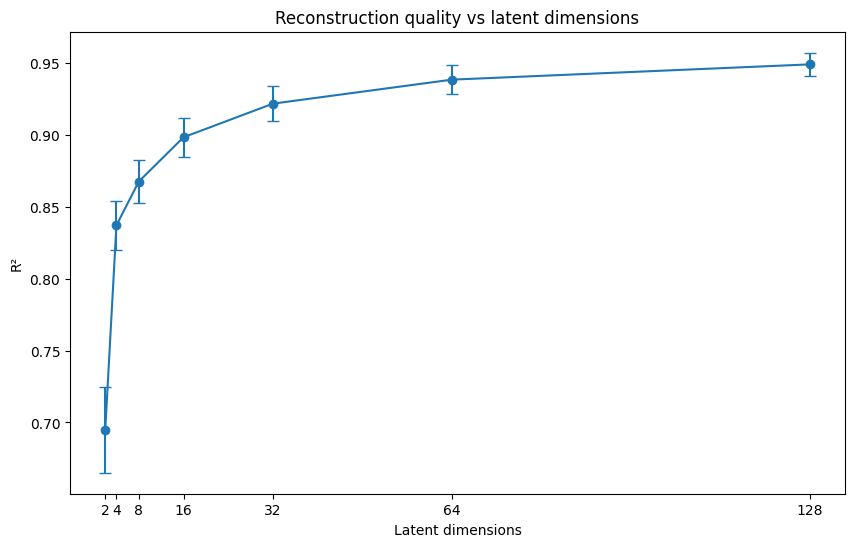

In [8]:
_LATENT_DIMS = [2, 4, 8, 16, 32, 64, 128]
means    = [results[tag]['r2']['mean'] for tag in results if tag not in ['latent6_zscore_cosinelr', 'latent12_zscore_cosinelr']]
std_errs = [results[tag]['r2']['std_err'] for tag in results if tag not in ['latent6_zscore_cosinelr', 'latent12_zscore_cosinelr']]

plt.figure(figsize=(10,6))
plt.errorbar(np.array(_LATENT_DIMS), means, yerr=std_errs, marker='o', capsize=4)
# plt.xscale('log')
plt.xlabel("Latent dimensions")
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
plt.xticks(_LATENT_DIMS)
plt.ylabel("R²")
plt.title("Reconstruction quality vs latent dimensions")
plt.show()

In [1]:
# plot reconstructions of different brain slices 

# Cox models for all dims 
- plot of concordance index vs dimension (note: clinical + latent lines on this plot?)
    - **maybe that should be on after running the below tests where I choose the best hidden dims and then rank them and then check what the best amount for test c-index is?**
- emmm but cox on all latent codes or just one? or sth like the plot Joan had - cox when adding next PCAs?
- **so for each latent dim: fitting univariate cox for all latent codes and ordering them by most useful and then plotting concordance index when adding them vs naive(clinical)**
- **and doing that on both training and testing**
- how does the univariate vs multivariate cox work - running multivariate can show which components are the most significant and then univariate is just a model using the selected ones - so it might be better because it has less covariates? 
- ahhhh is it that if the pcs are ranked the concordance index is higher as compared to when unranked? it's the plot from the first OHBM results notebook? with many many lines - **this justifies running univariate for all dims and then ordering them** by c-index - or hazard? or p-value? **and then running cox by adding consecutive dims on train and test set to check the c-index and the best amount of added latent dims**
- or I'd have to change if the same holds for these latent dims bcst hey're not PCs?
- AH - and plotting training and test because the c-index on training increases with added components? and then the test verifies that; so with more added components the c-index decreases?
- or of cox on just the statistically significant dims? - would that be just another approach?
- and then possbily that we'll stick to the 4 dims one? 
- how do I interpret the concordance index and the p-value? so that I make the choice of the cox model based on that?

## Encode or load codes

In [9]:
from cox import (_get_or_encode, _build_df)
from utils import unpad_ucsf_ids

In [10]:
train_val_ids = splits["train"] + splits["val"]
test_ids      = splits["test"]
all_ids       = train_val_ids + test_ids

# unpadded set for df filtering after merge
train_val_set = {unpad_ucsf_ids(s) if "UCSF" in s else s for s in train_val_ids}


In [ ]:
with open(Path(base_cfg.jsons_dir) / "id_to_cohort.json") as f:
    id_to_cohort = json.load(f)

clinical = pd.read_csv(base_cfg.clinical_csv)
out_dir = Path(base_cfg.jsons_dir)
# summaries_dir = out_dir / "cox_summaries"
# summaries_dir.mkdir(parents=True, exist_ok=True)

results = {}
for dim in _LATENT_DIMS:
    run_cfg = Config()
    run_cfg.latent_dim       = dim
    run_cfg.normalisation    = "zscore"
    run_cfg.use_lr_scheduler = True

    logger.info("=== latent_dim=%d ===", dim)
    codes, ids = _get_or_encode(run_cfg, all_ids, id_to_cohort, stats, device)

2026-06-29 17:05:50,547 INFO === latent_dim=2 ===
2026-06-29 17:05:59,665 INFO Encoded (1001, 2) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent2_zscore_cosinelr
2026-06-29 17:05:59,665 INFO === latent_dim=4 ===
2026-06-29 17:06:08,359 INFO Encoded (1001, 4) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent4_zscore_cosinelr
2026-06-29 17:06:08,360 INFO === latent_dim=8 ===
2026-06-29 17:06:17,060 INFO Encoded (1001, 8) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent8_zscore_cosinelr
2026-06-29 17:06:17,061 INFO === latent_dim=16 ===
2026-06-29 17:06:25,949 INFO Encoded (1001, 16) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent16_zscore_cosinelr
2026-06-29 17:06:25,950 INFO === latent_dim=32 ===
2026-06-29 17:06:34,560 INFO Encoded (1001, 32) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent32_zscore_cosinelr
2026-06-2

In [11]:
with open(Path(base_cfg.jsons_dir) / "id_to_cohort.json") as f:
    id_to_cohort = json.load(f)

clinical = pd.read_csv(base_cfg.clinical_csv)
out_dir = Path(base_cfg.jsons_dir)

run_cfg = Config()
run_cfg.latent_dim       = 4
run_cfg.normalisation    = "zscore"
run_cfg.use_lr_scheduler = True
codes, ids = _get_or_encode(run_cfg, all_ids, id_to_cohort, stats, device)
df, z_cols = _build_df(codes, ids, clinical, 4)

2026-06-30 00:15:43,040 INFO Loading cached codes from /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent4_zscore_cosinelr


In [12]:
df

,z1,z2,z3,z4,id,ID,age,sex,eor,mgmt,...,Core lesion TDMap,Non-enhancing TDMap,Non-enhancing lesion TDMap,Enhancing TDMap,Enhancing lesion TDMap,Core+Enhancing TDMap,Core+Enhancing lesion TDMap,cohort,site,OS (days) - corrected
0,1.621464,-5.693500,35.877537,-4.840298,UPENN-GBM-00147_11,UPENN-GBM-00147_11,82.41,1,1.0,0.0,...,0.804185,130.299588,2.866155,74.560762,1.046598,100.428056,1.047600,1,1,107.143828
1,12.845091,-1.782956,26.826283,-24.796284,UCSF-PDGM-430,UCSF-PDGM-430,79.00,0,2.0,0.0,...,0.214835,255.461534,2.799048,133.118295,0.736955,123.039131,0.736956,0,0,406.000000
2,21.200544,18.810493,4.611731,-28.574509,UCSF-PDGM-472,UCSF-PDGM-472,76.00,1,0.0,2.0,...,1.278647,124.437120,4.896154,117.381894,2.580636,123.730019,2.580733,0,0,38.000000
3,13.924551,-10.392248,24.448484,-0.469693,UCSF-PDGM-332,UCSF-PDGM-332,68.00,0,2.0,2.0,...,0.736385,175.369296,5.865094,146.804520,1.725475,148.421375,1.725487,0,0,42.000000
4,0.680297,-6.521086,6.852678,5.157828,UPENN-GBM-00337_11,UPENN-GBM-00337_11,62.34,0,2.0,NaN,...,2.775009,112.819121,4.693732,157.227826,3.901126,166.981916,3.917241,1,1,515.629674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,-8.085268,22.565022,0.704565,-9.653357,TCGA-02-0009,TCGA-02-0009,61.00,1,NaN,0.0,...,0.379249,70.014250,1.257232,148.231487,0.614384,88.865209,0.650983,2,1,430.967790
995,16.352362,-11.631674,23.623861,-10.405519,TCGA-06-0238,TCGA-06-0238,46.00,0,NaN,NaN,...,0.466644,99.463595,3.751923,56.781503,0.673405,54.285974,0.678839,2,1,542.055761
996,17.940706,14.994812,-19.931723,-23.902170,TCGA-76-6664,TCGA-76-6664,49.00,1,NaN,2.0,...,0.462849,93.481570,3.777519,46.345565,0.955934,45.520411,1.009172,2,1,317.203001
997,8.373868,-16.543245,24.541079,6.661209,TCGA-06-0241,TCGA-06-0241,65.00,1,NaN,NaN,...,0.780565,171.162536,1.740584,97.543244,1.220562,107.294998,1.223833,2,1,608.976225


## Train and test split prep

In [13]:
# split the whole cohort into test and train
# do I have to also account for the censoring or not? how?
from sklearn.model_selection import train_test_split

# Combined stratification key: e.g. "ucsf_censored", "upenn_uncensored", etc.
df["strat_key"] = df["cohort"].astype(str) + "_" + df["status"].astype(str)

print("Stratification group sizes:")
print(df["strat_key"].value_counts().sort_index())

train_idx, test_idx = train_test_split(
    df.index, # RangeIndex object
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["strat_key"]
)

df_train = df.loc[train_idx] # --> NOT OBVIOUS HOW TO RECOVER THE CORRECT ORDER FOR THE SURVIVAL COMPUTATIONS
df_test  = df.loc[test_idx]

# Verify
for split_name, split_df in [("Train", df_train), ("Test", df_test)]:
    print(f"\n{split_name} (N={len(split_df)}):")
    print("  Cohort proportions:\n", split_df["cohort"].value_counts(normalize=True).round(3))
    print("  Censoring rate:    ", (split_df["status"] == 0).mean().round(3))

Stratification group sizes:
strat_key
0_0.0    144
0_1.0    223
1_0.0     14
1_1.0    482
2_0.0     21
2_1.0     82
3_0.0      9
3_1.0     24
Name: count, dtype: int64

Train (N=799):
  Cohort proportions:
 cohort
1    0.497
0    0.367
2    0.104
3    0.033
Name: proportion, dtype: float64
  Censoring rate:     0.188

Test (N=200):
  Cohort proportions:
 cohort
1    0.495
0    0.370
2    0.100
3    0.035
Name: proportion, dtype: float64
  Censoring rate:     0.19


## For 4-dim latent codes

In [ ]:
# run univariate on each dim and plot importance of each element z1, z2...
# order by best and plot c-index by adding consecutive "best" components on train and test 
# also plot clinical only c-index - so a line? bcs this would be the baseline

# and then do that for all dimensions? 
# see what the best c-index is - and choose that model as the final one?

In [17]:
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


DURATION_COL     = "OS (days) - corrected"
EVENT_COL        = "status"
CLINICAL_COLS    = ["age", "sex"]

Cindices_training, HRs_uni, HRs_uni_pval = {}, {}, {}
Cindices_testing = {}

for dim in range(4):
    cph_uni = CoxPHFitter(
        penalizer=0.1,
        l1_ratio=0.01,
        baseline_estimation_method="breslow" 
    )
    
    try:
        # Train Cox
        cph_uni.fit(
            df_train[[f"z{dim+1}", DURATION_COL, EVENT_COL]], 
            DURATION_COL, 
            EVENT_COL,
            show_progress=False
        )
        Cindices_training[dim] = cph_uni.concordance_index_
        HRs_uni[dim] = [cph_uni.hazard_ratios_.values[0], np.exp(cph_uni.confidence_intervals_.values[0][0]), np.exp(cph_uni.confidence_intervals_.values[0][1])]
        HRs_uni_pval[dim] = cph_uni.summary['p'].values[0]
        
        # Test Cox
        df_tst = df_test[[f"z{dim+1}", DURATION_COL, EVENT_COL]]
        Cindices_testing[dim] = concordance_index(
            df_tst[DURATION_COL], 
            -cph_uni.predict_partial_hazard(df_tst), 
            df_tst[EVENT_COL]
        )
    except Exception as e:
        print(f"Skipped {dim} due to error: {e}")
        Cindices_training[dim] = 0.0 # Failed components receive zero power
        Cindices_testing[dim] = 0.0 # Failed components receive zero power

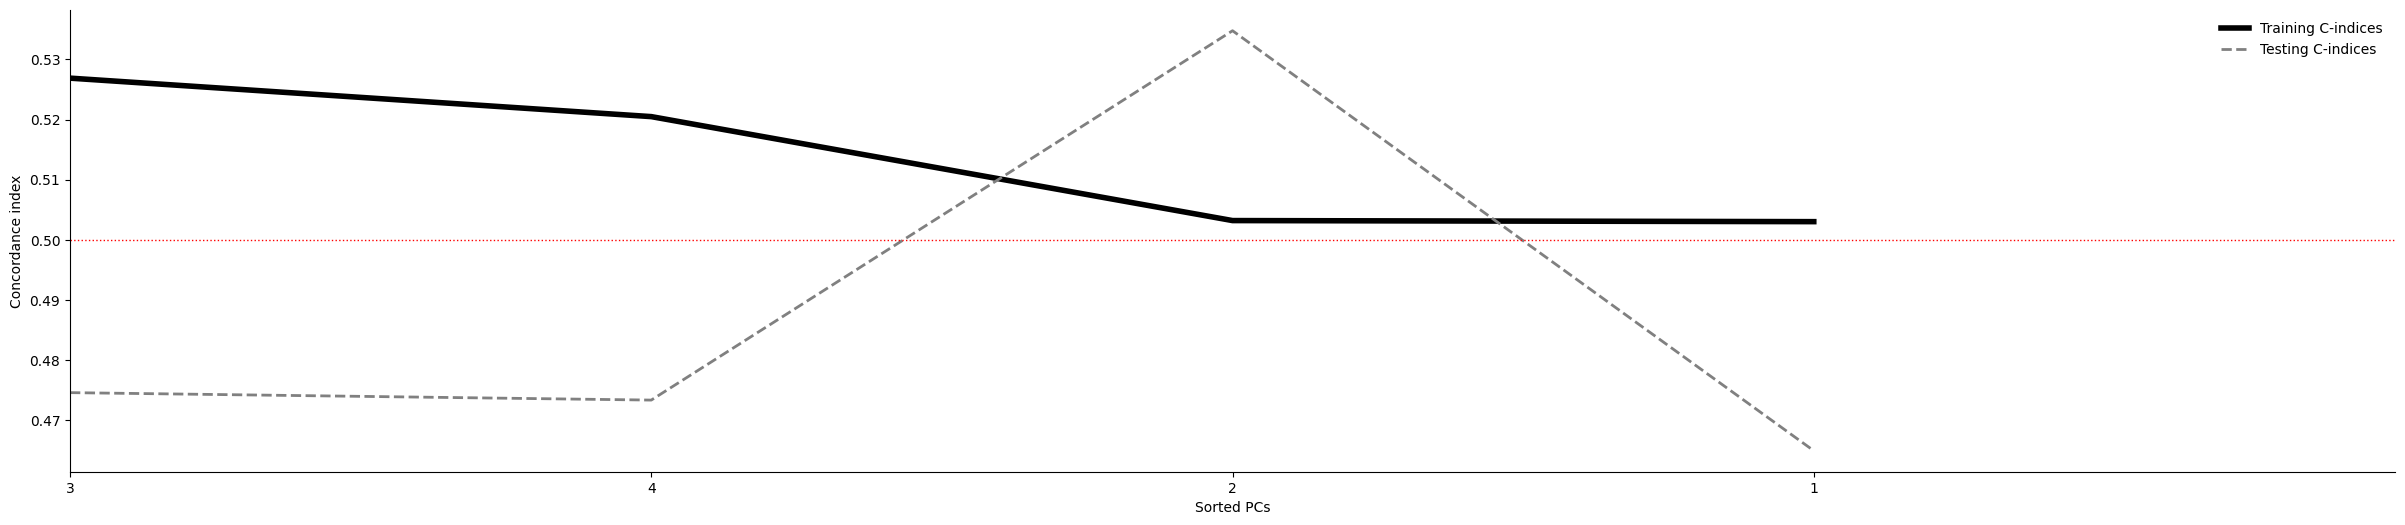

In [20]:
# Sort from strongest to weakest
mode = "training"
components_sorted_by_power = sorted(
    Cindices_training if mode=="training" else Cindices_testing, 
    key=Cindices_training.get if mode=="training" else Cindices_testing.get, 
    reverse=True
)
# os.makedirs(f"{save_dir}/sorting-{mode}", exist_ok=True)

sorted_Cindices_training = np.array([Cindices_training[ii] for ii in components_sorted_by_power])
sorted_Cindices_testing = np.array([Cindices_testing[ii] for ii in components_sorted_by_power])

fig, ax = plt.subplots(1, 1, figsize=(30,6))

ax.plot(sorted_Cindices_training, label="Training C-indices", linewidth=4, linestyle="solid", color="black")
ax.plot(sorted_Cindices_testing, label="Testing C-indices", linewidth=2, linestyle="dashed", color="gray")
ax.plot([0, 4], [0.5, 0.5], linewidth=1, linestyle="dotted", color="red")

ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(range(0,4))
ax.set_xticklabels(np.array(components_sorted_by_power)+1)
ax.set_xlim([0,4])
ax.set_xlabel("Sorted PCs")
ax.set_ylabel("Concordance index")

ax.legend(frameon=False)

# fig.tight_layout()
# fig.savefig(f"{save_dir}/sorting-{mode}/C-indices_sorted-{mode}.{fmt}", dpi=200, format=fmt)

Text(0, 0.5, 'Hazard ratio ($\\exp [\\beta]$)')

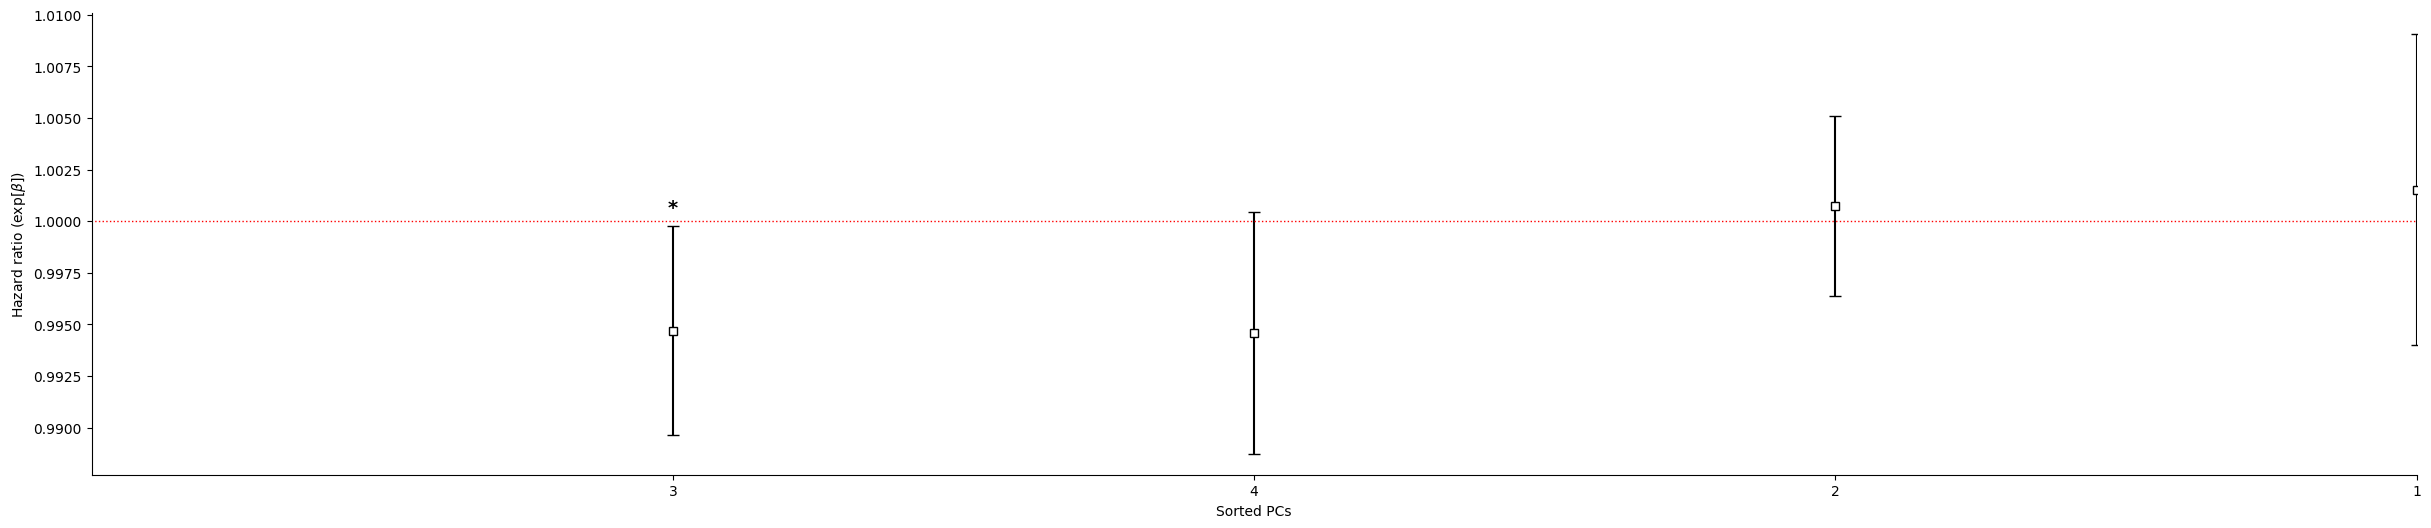

In [24]:
sorted_HRs_uni = np.array([HRs_uni[ii] for ii in components_sorted_by_power])

fig, ax = plt.subplots(1, 1, figsize=(30,6))

ax.errorbar(
    x=range(1,5), 
    y=sorted_HRs_uni[:,0], 
    yerr=np.array([sorted_HRs_uni[:,0]-sorted_HRs_uni[:,1],sorted_HRs_uni[:,2]-sorted_HRs_uni[:,0]]),
    fmt='s',
    markeredgecolor='black',
    markerfacecolor='white',
    capsize=4,
    ecolor='black'
)
for x, comp in enumerate(components_sorted_by_power):

    p = HRs_uni_pval[comp]

    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        continue

    # place stars slightly above the upper CI
    y = sorted_HRs_uni[x, 2]

    ax.text(
        x+1,
        y + 0.02 * (sorted_HRs_uni[:,2].max() - sorted_HRs_uni[:,1].min()),
        stars,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )
ax.plot([-1, 4], [1, 1], linewidth=1, linestyle="dotted", color="red")

ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(range(1,5))
ax.set_xticklabels(np.array(components_sorted_by_power)+1)
ax.set_xlim([0,4])
ax.set_xlabel("Sorted PCs")
ax.set_ylabel("Hazard ratio ("+r'$\exp [\beta]$'+")")

# fig.tight_layout()
# fig.savefig(f"{save_dir}/sorting-{mode}/Hazard-ratios_sorted-{mode}.{fmt}", dpi=200, format=fmt)

In [28]:
from tqdm import tqdm
Cindices_training_CoxSorted = {}
Cindices_testing_CoxSorted = {}
logHRs_CoxSorted = {}

for k in tqdm(range(1,5), desc="Fitting Cox models with incremental components"):
    
    # Take the top k most important components
    included_components = components_sorted_by_power[:k]

    cph_multi = CoxPHFitter(
        penalizer=0.1,
        l1_ratio=0.01,
        baseline_estimation_method="breslow" 
    )
    
    try:
        # Train Cox
        cph_multi.fit(
            df_train[[f"z{dim+1}" for dim in included_components]+ [DURATION_COL, EVENT_COL, "age", "sex"]], 
            DURATION_COL,
            EVENT_COL,
            show_progress=False
        )
        Cindices_training_CoxSorted[k] = cph_multi.concordance_index_
        logHRs_CoxSorted[k] = cph_multi.params_.values

        # Test Cox
        df_tst = df_test[[f"z{dim+1}" for dim in included_components]+ [DURATION_COL, EVENT_COL, "age", "sex"]]
        Cindices_testing_CoxSorted[k] = concordance_index(
            df_tst[DURATION_COL], 
            -cph_multi.predict_partial_hazard(df_tst), 
            df_tst[EVENT_COL]
        )

    except Exception as e:
        print(f"Fitting error for k={k} components: {e}")
        continue

## Naaive model including only clinical data
cph_naive = CoxPHFitter(
        penalizer=0,
        l1_ratio=0,
        baseline_estimation_method="breslow" 
    )
cph_naive.fit(
    df_train[[DURATION_COL, EVENT_COL, "age", "sex"]], 
    DURATION_COL, 
    EVENT_COL,
    show_progress=False
)
Cindex_training_naive = cph_naive.concordance_index_
df_tst = df_test[[DURATION_COL, EVENT_COL, "age", "sex"]]
Cindex_testing_naive = concordance_index(
    df_tst[DURATION_COL], 
    -cph_naive.predict_partial_hazard(df_tst), 
    df_tst[EVENT_COL]
)

Fitting Cox models with incremental components: 100%|██████████| 4/4 [00:00<00:00,  5.92it/s]


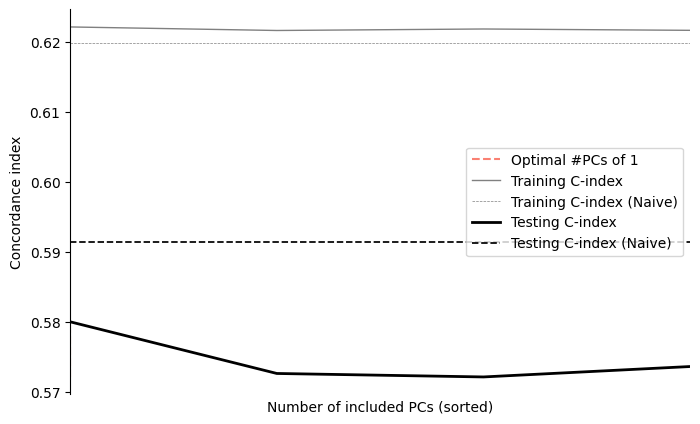

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

to_include_PCs = np.array(list(Cindices_testing_CoxSorted.values())).argmax()
to_included_PCs_Cindex = np.array(list(Cindices_testing_CoxSorted.values())).max()
ax.plot(
    [to_include_PCs, to_include_PCs], 
    [np.array(list(Cindices_testing_CoxSorted.values())).min(), to_included_PCs_Cindex],
    linestyle="dashed",
    color="salmon",
    label=f"Optimal #PCs of {1+to_include_PCs}"
)

ax.plot(Cindices_training_CoxSorted.values(), linestyle='solid', linewidth=1, color="gray", label="Training C-index")
ax.plot([0, 3], [Cindex_training_naive, Cindex_training_naive], linestyle='dashed', linewidth=.5, color="gray", label="Training C-index (Naive)")

ax.plot(Cindices_testing_CoxSorted.values(), linestyle='solid', linewidth=2, color="black", label="Testing C-index")
ax.plot([0, 3], [Cindex_testing_naive, Cindex_testing_naive], linestyle='dashed', linewidth=1.25, color="black", label="Testing C-index (Naive)")

ax.spines[["top","right","bottom"]].set_visible(False)
ax.set_xticks([])
ax.set_ylabel("Concordance index")
ax.set_xlabel("Number of included PCs (sorted)")
ax.set_xlim([0,3])

ax.legend(frameon=True, loc="right")

# fig.tight_layout()
# fig.savefig(f"{save_dir}/sorting-{mode}/Final-Cox_C-index_sorted-{mode}.{fmt}", dpi=200, format=fmt)

# Cox models - clinical, latent, clinical + latent
- [ ]  compute C-index on train AND on test
- [ ]  log-likelihood
- [ ]  from lifelines
- [ ]  in Joan’s code

# Survival plots - low high risk

# Anatomical relevance?